In [5]:
print("Hello")

Hello


In [6]:
from google.colab import files
uploaded = files.upload()

Saving adult_data_final1.csv to adult_data_final1 (1).csv


In [25]:
import pandas as pd

df = pd.read_csv("adult_data_final1.csv")
df.head()

,Unnamed: 0,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0,39,govt,77516,Graduate,13,Single,White-Collar,Not-Family,White,Male,2174,0,40,US,<=50K
1,1,50,self_emp,83311,Graduate,13,Married,White-Collar,Family,White,Male,0,0,13,US,<=50K
2,2,38,private,215646,NonGraduate,9,Separated,Blue-Collar,Not-Family,White,Male,0,0,40,US,<=50K
3,3,53,private,234721,NonGraduate,7,Married,Blue-Collar,Family,Black,Male,0,0,40,US,<=50K
4,4,28,private,338409,Graduate,13,Married,White-Collar,Family,Black,Female,0,0,40,Non-US,<=50K


In [26]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [27]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [28]:
df.shape

(47592, 15)

In [29]:
#Drop null values
(df.isnull().sum()/df.shape[0]*100)

,0
age,0.000000
workclass,3.857791
fnlwgt,0.000000
education,0.000000
education-num,0.000000
marital-status,0.000000
occupation,3.872500
relationship,0.000000
race,0.000000
sex,0.000000


In [30]:
df.dropna(axis=0,inplace=True)

In [31]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [32]:
df.workclass.unique()

array(['govt', 'self_emp', 'private', 'un_emp'], dtype=object)

In [33]:
from sklearn.preprocessing import StandardScaler
st_scale = StandardScaler()
num_col = df.select_dtypes(include="number").columns
print(num_col)
for i in num_col:
    df[i] = st_scale.fit_transform(df[[i]])

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


In [34]:
from sklearn.preprocessing import LabelEncoder
lab_enc = LabelEncoder()
cat_col = df.select_dtypes(include="object").columns
for i in cat_col:
    df[i] = lab_enc.fit_transform(df[i])

In [35]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.033918,0,-1.062310,0,1.128863,2,2,1,4,1,0.142754,-0.218851,-0.078393,1,0
1,0.866264,2,-1.007453,0,1.128863,0,2,0,4,1,-0.146780,-0.218851,-2.327209,1,0
2,-0.041750,1,0.245251,1,-0.438517,1,0,1,4,1,-0.146780,-0.218851,-0.078393,1,0
3,1.093267,1,0.425818,1,-1.222207,0,0,0,2,1,-0.146780,-0.218851,-0.078393,1,0
4,-0.798428,1,1.407344,0,1.128863,0,2,0,2,0,-0.146780,-0.218851,-0.078393,0,0


In [36]:
X = df.drop("income",axis=1)
y = df["income"]

In [37]:
X

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.033918,0,-1.062310,0,1.128863,2,2,1,4,1,0.142754,-0.218851,-0.078393,1
1,0.866264,2,-1.007453,0,1.128863,0,2,0,4,1,-0.146780,-0.218851,-2.327209,1
2,-0.041750,1,0.245251,1,-0.438517,1,0,1,4,1,-0.146780,-0.218851,-0.078393,1
3,1.093267,1,0.425818,1,-1.222207,0,0,0,2,1,-0.146780,-0.218851,-0.078393,1
4,-0.798428,1,1.407344,0,1.128863,0,2,0,2,0,-0.146780,-0.218851,-0.078393,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47587,-0.420089,1,0.525118,0,1.128863,2,2,0,4,1,-0.146780,-0.218851,-0.078393,1
47588,0.033918,1,0.243102,0,1.128863,1,2,1,4,0,-0.146780,-0.218851,-0.411551,1
47589,-0.041750,1,1.753560,0,1.128863,0,2,0,4,1,-0.146780,-0.218851,0.754502,1
47590,0.412257,1,-1.001963,0,1.128863,1,2,0,1,1,0.579719,-0.218851,-0.078393,1


In [38]:
y

,income
0,0
1,0
2,0
3,0
4,0
...,...
47587,0
47588,0
47589,0
47590,0


In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [40]:
input_dim = X_train.shape[1]

# Model Building

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [43]:
model = Sequential()
model.add(Dense(32,activation='relu',input_shape = (input_dim,)))
model.add(Dense(64,activation='relu'))
model.add(Flatten())
model.add(Dense(1,activation='sigmoid'))

In [47]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [49]:
history = model.fit(X_train,y_train,
            validation_data = (X_test,y_test),
            epochs = 50)

Epoch 1/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8302 - loss: 0.3603 - val_accuracy: 0.8451 - val_loss: 0.3379
Epoch 2/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8469 - loss: 0.3315 - val_accuracy: 0.8452 - val_loss: 0.3313
Epoch 3/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8482 - loss: 0.3278 - val_accuracy: 0.8488 - val_loss: 0.3261
Epoch 4/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8497 - loss: 0.3251 - val_accuracy: 0.8484 - val_loss: 0.3248
Epoch 5/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8514 - loss: 0.3225 - val_accuracy: 0.8494 - val_loss: 0.3255
Epoch 6/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8522 - loss: 0.3214 - val_accuracy: 0.8513 - val_loss: 0.3228
Epoch 7/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8517 - loss: 0.3196 - val_accuracy: 0.8484 - val_loss: 0.3231
Epoch 8/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8522 - loss: 0.3184 - val_accuracy: 0.

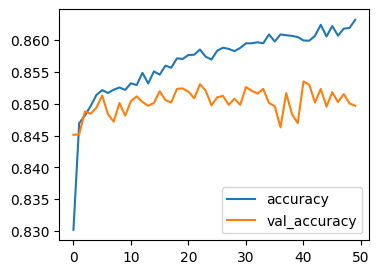

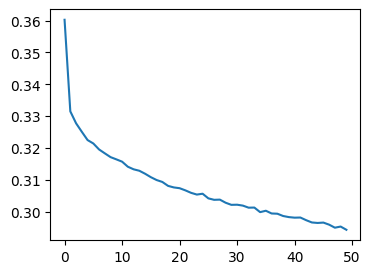

In [50]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(history.history['accuracy'],label ='accuracy')
plt.plot(history.history['val_accuracy'],label ='val_accuracy')
plt.legend()
plt.show()

import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(history.history['loss'],label = 'loss')

In [51]:
model.save("ANN_model.h5")